In [45]:
!pip install pymysql sqlalchemy pandas openpyxl -q

import pandas as pd
from sqlalchemy import create_engine, text

In [4]:
from google.colab import files
uploaded = files.upload()   # select account.csv, card.csv, client.csv, disp.csv,
                             # district.csv, loan.csv, order.csv,
                             # trnx_16.csv, trnx_17.csv, trnx_18.csv,
                             # trnx_19_NEW.csv, trnx_20_NEW.csv, trnx_21_NEW.csv


Saving ca.pem to ca.pem
Saving trnx_19_NEW.csv to trnx_19_NEW (2).csv
Saving trnx_17.csv to trnx_17 (2).csv
Saving trnx_18.csv to trnx_18 (2).csv
Saving trnx_20_NEW.csv to trnx_20_NEW (2).csv
Saving trnx_21_NEW.csv to trnx_21_NEW (2).csv
Saving account.csv to account (2).csv
Saving card.csv to card (2).csv
Saving client.csv to client (2).csv
Saving disp.csv to disp (2).csv
Saving district.csv to district (2).csv
Saving loan.csv to loan (2).csv
Saving order.csv to order (2).csv
Saving trnx_16.csv to trnx_16 (2).csv


In [5]:
account = pd.read_csv("account.csv")
card = pd.read_csv("card.csv", sep=";")
client = pd.read_csv("client.csv", sep=";")
disp = pd.read_csv("disp.csv")
district = pd.read_csv("district.csv")
loan = pd.read_csv("loan.csv", sep=";")
order = pd.read_csv("order.csv")

trnx_files = ["trnx_16.csv", "trnx_17.csv", "trnx_18.csv",
              "trnx_19_NEW.csv", "trnx_20_NEW.csv", "trnx_21_NEW.csv"]
transaction = pd.concat([pd.read_csv(f) for f in trnx_files], ignore_index=True)

print(account.shape, card.shape, client.shape, disp.shape,
      district.shape, loan.shape, order.shape, transaction.shape)
# expect: (4500,5) (892,4) (5369,3) (5369,4) (77,16) (682,7) (6471,5) (1048575,10)

/tmp/ipykernel_986/2903166927.py:11: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  transaction = pd.concat([pd.read_csv(f) for f in trnx_files], ignore_index=True)


(4500, 5) (892, 4) (5369, 3) (5369, 4) (77, 16) (682, 7) (6471, 5) (1048575, 10)


In [6]:
def shift_yymmdd(series, years=23):
    """Parses YYMMDD int/str and adds `years`."""
    dt = pd.to_datetime(series.astype(str).str.zfill(6), format='%y%m%d')
    return dt + pd.DateOffset(years=years)

account['open_date'] = shift_yymmdd(account['date'])
loan['loan_date'] = shift_yymmdd(loan['date'])

# card.issued has a " 00:00:00" suffix — strip to first 6 chars before parsing
card['issue_date'] = shift_yymmdd(card['issued'].astype(str).str[:6])

# transaction dates are already real — no shift
transaction['Date'] = pd.to_datetime(transaction['Date'])

In [16]:
def decode_birth(birth_number):
    yy = birth_number // 10000
    mm_raw = (birth_number % 10000) // 100
    dd = birth_number % 100
    gender = 'F' if mm_raw > 50 else 'M'
    mm = mm_raw - 50 if mm_raw > 50 else mm_raw
    year = 1900 + yy + 23

    # Construct a string in a format that pd.to_datetime can parse
    # This also handles invalid dates by coercing them to NaT
    date_str = f"{year:04d}-{mm:02d}-{dd:02d}"
    birth_date = pd.to_datetime(date_str, errors='coerce')

    return pd.Series({'gender': gender,
                       'birth_date': birth_date})

client[['gender', 'birth_date']] = client['birth_number'].apply(decode_birth)

# Ensure birth_date is datetime type (datetime64[ns]) before calculation
client['birth_date'] = pd.to_datetime(client['birth_date'], errors='coerce')

# Calculate age as float, which will have np.nan for invalid birth dates
age_in_years_float = (pd.Timestamp.today() - client['birth_date']).dt.days / 365.25

# Round the float values to the nearest integer and then convert to nullable integer.
# This handles np.nan values by preserving them and then converting to pd.NA.
client['age'] = age_in_years_float.round().astype('Int64')

# Sanity check — should be roughly 11 to 87, mean ~45
print(client['age'].describe())

count       5366.0
mean     49.862281
std      17.290626
min           16.0
25%           35.0
50%           49.0
75%           63.0
max           92.0
Name: age, dtype: Float64


In [17]:
freq_map = {
    'POPLATEK MESICNE': 'Monthly Statement',
    'POPLATEK TYDNE': 'Weekly Statement',
    'POPLATEK PO OBRATU': 'Statement After Transaction'
}
account['frequency'] = account['frequency'].map(freq_map)

order['Bank_to'] = order['Bank_to'].str.strip()

transaction['Purpose'] = transaction['Purpose'].str.strip().replace('', 'None').fillna('None')
transaction['Type'] = transaction['Type'].str.strip()
transaction['operation'] = transaction['operation'].str.strip()

In [18]:
status_map = {'A': 'Finished - OK', 'B': 'Finished - Default',
              'C': 'Running - OK', 'D': 'Running - In Debt'}
loan['status_label'] = loan['status'].map(status_map)
loan['is_default_flag'] = loan['status'].isin(['B', 'D']).astype(int)

In [19]:
import numpy as np

q1, q3 = np.percentile(transaction['amount'], [25, 75])
iqr = q3 - q1
transaction['is_outlier'] = (
    (transaction['amount'] > q3 + 1.5 * iqr) |
    (transaction['amount'] < q1 - 1.5 * iqr)
)
print(f"{transaction['is_outlier'].sum()} outlier transactions flagged")

119182 outlier transactions flagged


In [20]:
print("Duplicate trans_id:", transaction['trans_id'].duplicated().sum())
print("Duplicate client_id:", client['client_id'].duplicated().sum())

Duplicate trans_id: 0
Duplicate client_id: 0


In [21]:
client['age_group'] = pd.cut(client['age'], bins=[0,17,25,35,50,65,120],
                              labels=['Under 18','18-25','26-35','36-50','51-65','65+'])

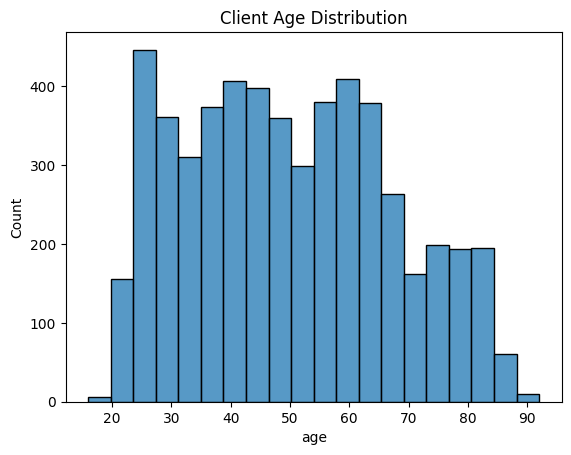

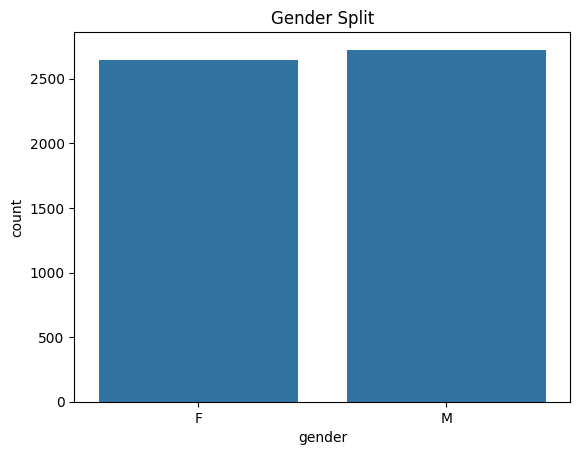

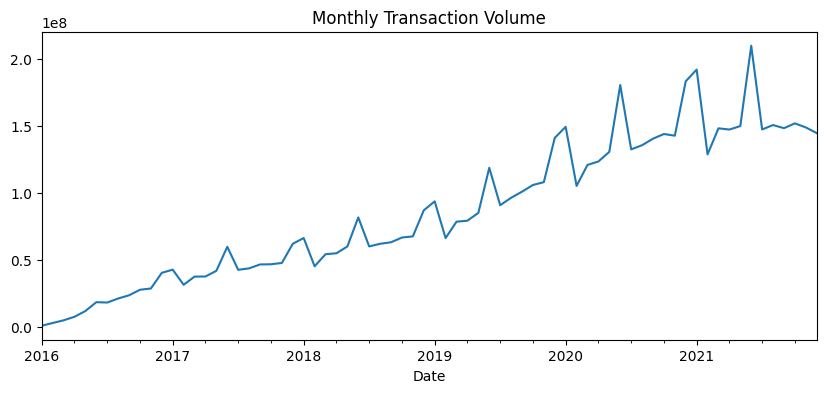

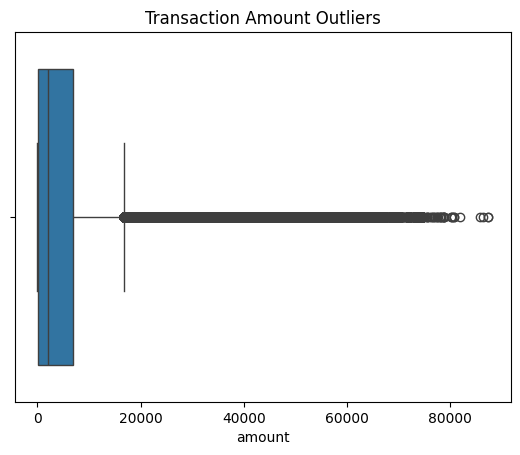

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(client['age'], bins=20); plt.title("Client Age Distribution"); plt.show()
print()
sns.countplot(data=client, x='gender'); plt.title("Gender Split"); plt.show()
print()

transaction.groupby(transaction['Date'].dt.to_period('M'))['amount'].sum().plot(
    title="Monthly Transaction Volume", figsize=(10,4)); plt.show()
print()
sns.boxplot(x=transaction['amount']); plt.title("Transaction Amount Outliers"); plt.show()

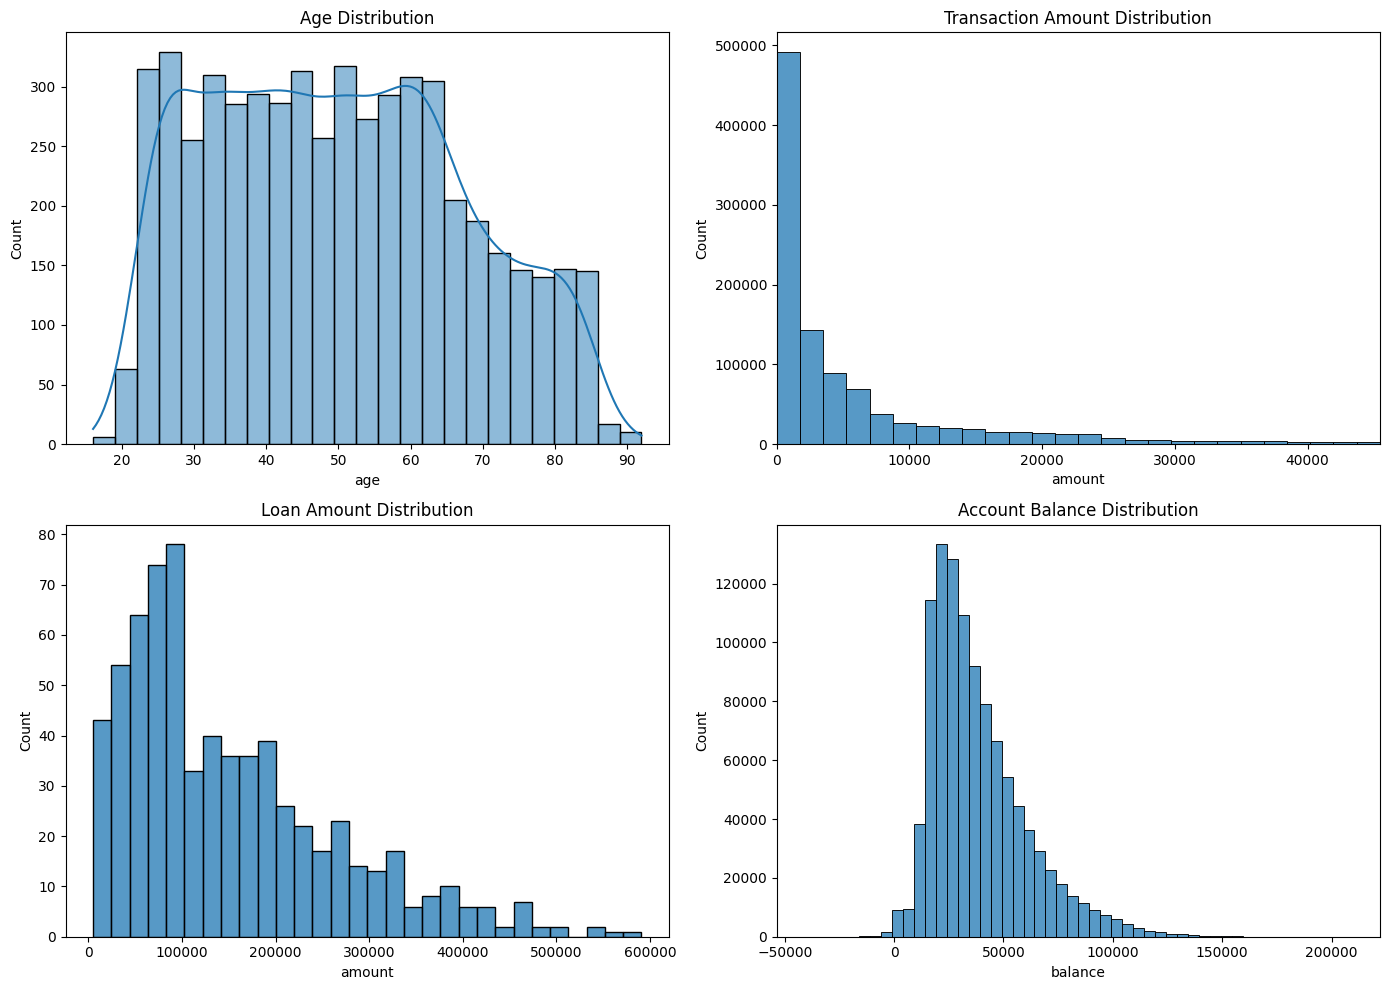

count    1.048575e+06
mean     5.942153e+03
std      9.529357e+03
min      0.000000e+00
25%      1.360000e+02
50%      2.100000e+03
75%      6.817000e+03
max      8.740000e+04
Name: amount, dtype: float64
count       682.000000
mean     151410.175953
std      113372.406310
min        4980.000000
25%       66732.000000
50%      116928.000000
75%      210654.000000
max      590820.000000
Name: amount, dtype: float64


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(client['age'], bins=25, kde=True, ax=axes[0,0]); axes[0,0].set_title("Age Distribution")
sns.histplot(transaction['amount'], bins=50, ax=axes[0,1]); axes[0,1].set_title("Transaction Amount Distribution")
axes[0,1].set_xlim(0, transaction['amount'].quantile(0.99))  # trim extreme tail for a readable view
sns.histplot(loan['amount'], bins=30, ax=axes[1,0]); axes[1,0].set_title("Loan Amount Distribution")
sns.histplot(transaction['balance'], bins=50, ax=axes[1,1]); axes[1,1].set_title("Account Balance Distribution")
plt.tight_layout(); plt.show()

print(transaction['amount'].describe())
print(loan['amount'].describe())

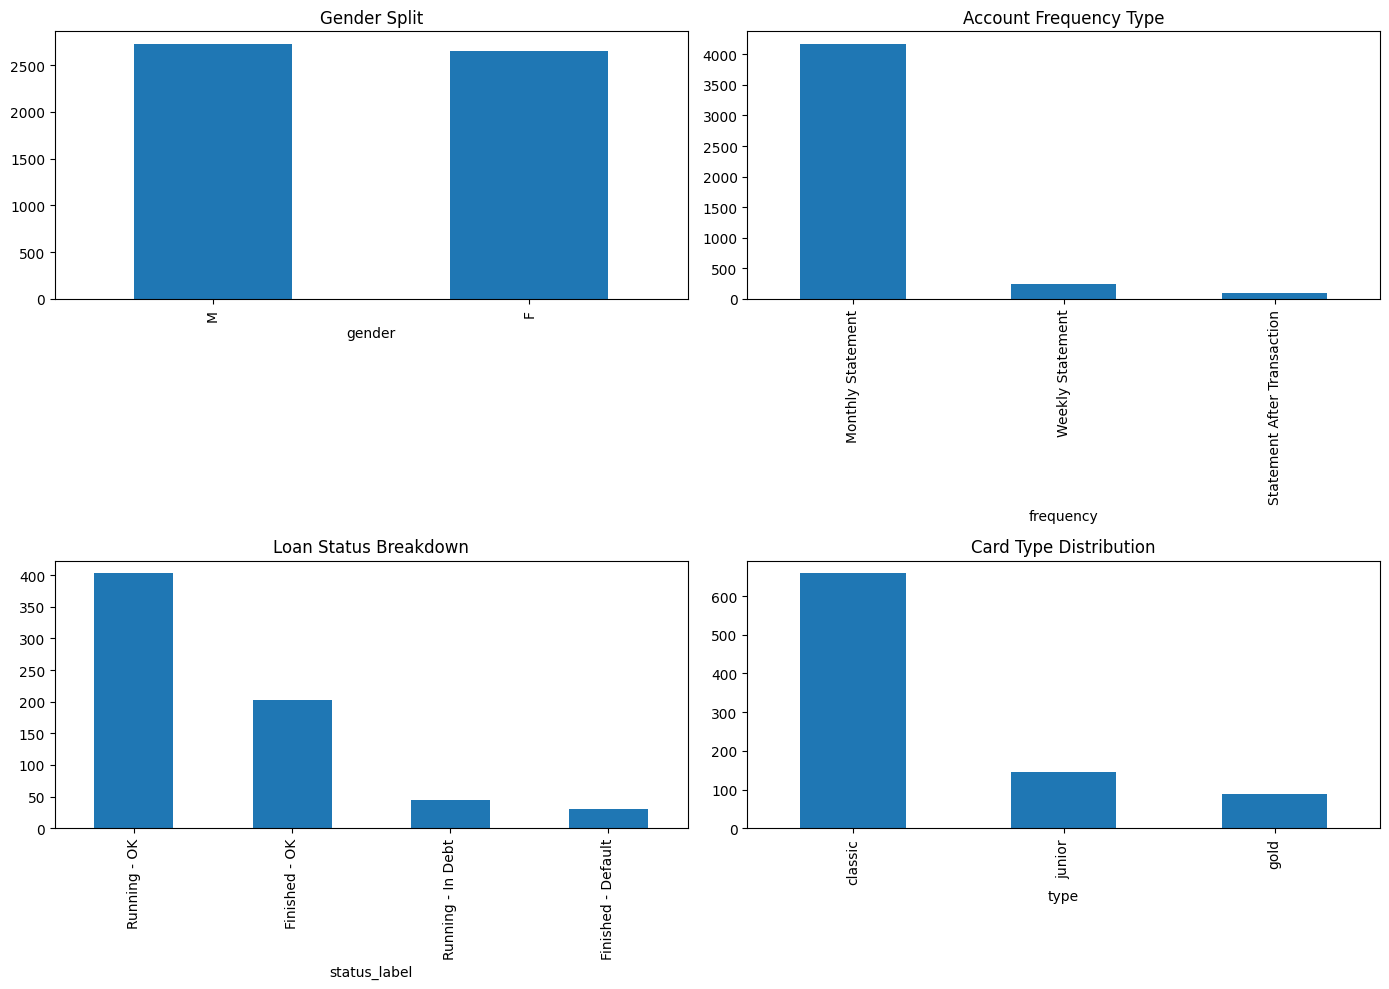

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
client['gender'].value_counts().plot(kind='bar', ax=axes[0,0], title="Gender Split")
account['frequency'].value_counts().plot(kind='bar', ax=axes[0,1], title="Account Frequency Type")
loan['status_label'].value_counts().plot(kind='bar', ax=axes[1,0], title="Loan Status Breakdown")
card['type'].value_counts().plot(kind='bar', ax=axes[1,1], title="Card Type Distribution")
plt.tight_layout(); plt.show()

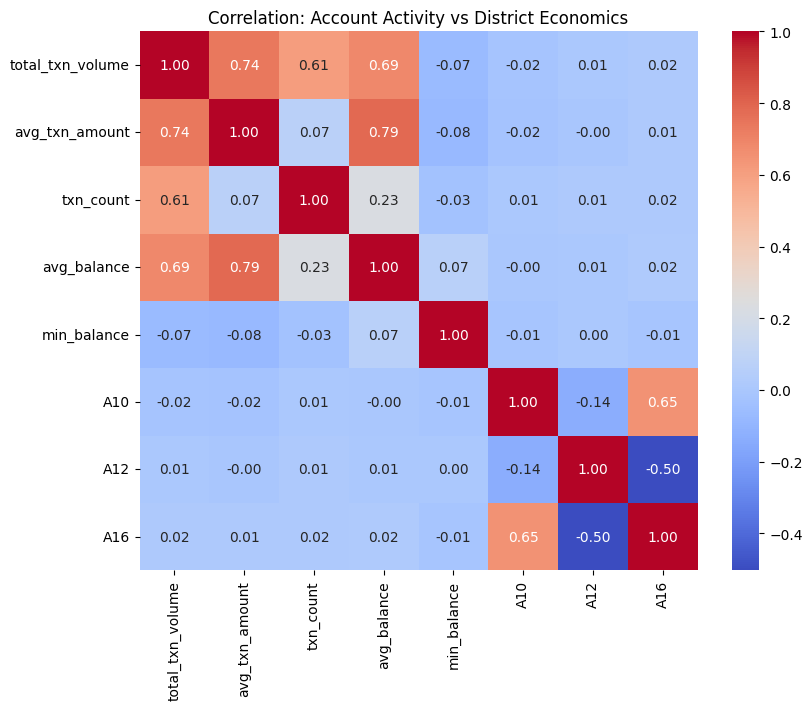

In [31]:
account_agg = transaction.groupby('account_id').agg(
    total_txn_volume=('amount', 'sum'),
    avg_txn_amount=('amount', 'mean'),
    txn_count=('trans_id', 'count'),
    avg_balance=('balance', 'mean'),
    min_balance=('balance', 'min')
).reset_index()

account_full = account.merge(account_agg, on='account_id', how='left') \
                       .merge(district, left_on='district_id', right_on='A1', how='left')

numeric_cols = ['total_txn_volume', 'avg_txn_amount', 'txn_count', 'avg_balance',
                 'min_balance', 'A10', 'A12', 'A16'] # Using A10 for avg_salary, A12 for unemployment_rate, A16 for urban_ratio
plt.figure(figsize=(9,7))
sns.heatmap(account_full[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation: Account Activity vs District Economics")
plt.show()

/tmp/ipykernel_986/389556588.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = transaction.set_index('Date').resample('M')['amount'].sum()


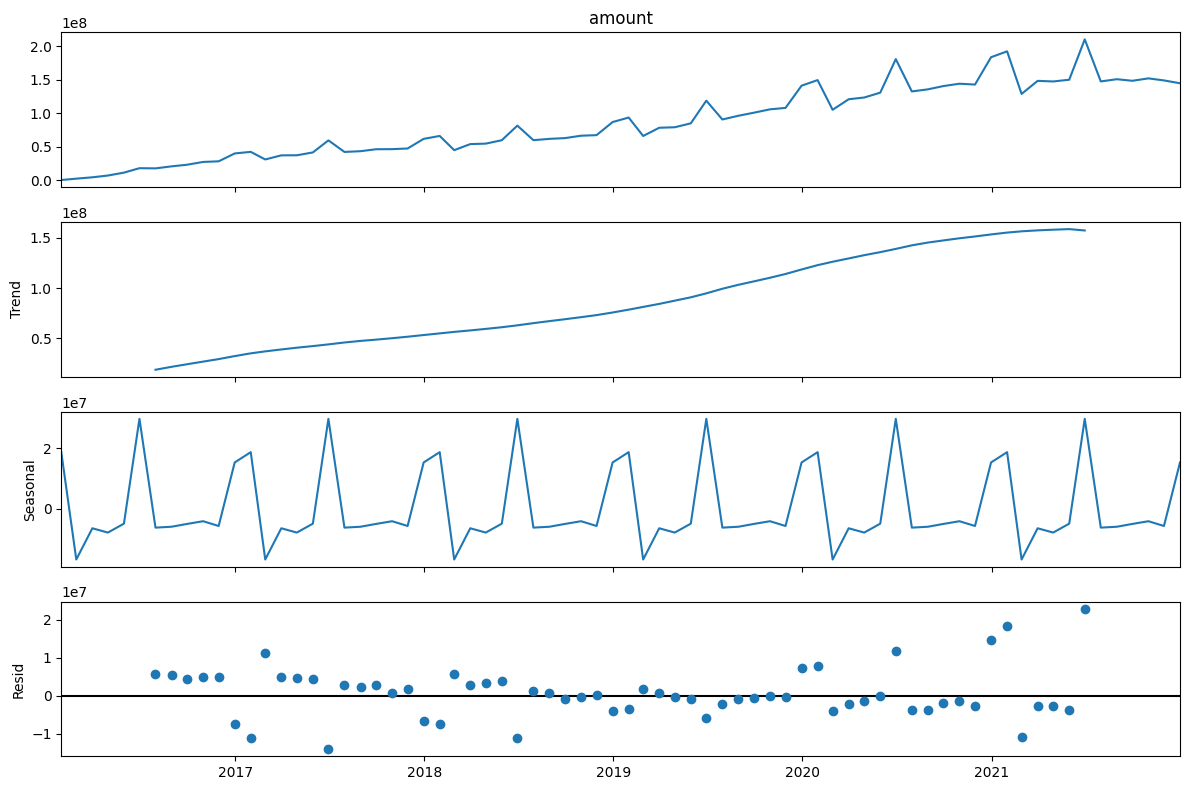

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly = transaction.set_index('Date').resample('M')['amount'].sum()

decomposition = seasonal_decompose(monthly, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout(); plt.show()

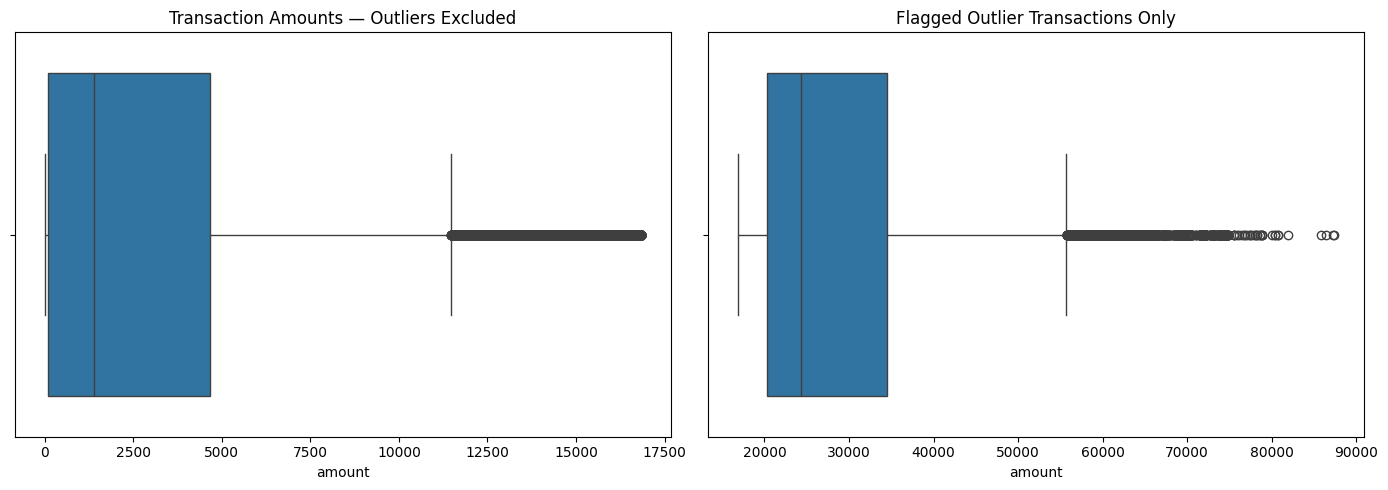

Outliers by type:
Type
Credit        78263
Withdrawal    40919
Name: count, dtype: int64


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=transaction[~transaction['is_outlier']]['amount'], ax=axes[0])
axes[0].set_title("Transaction Amounts — Outliers Excluded")
sns.boxplot(x=transaction[transaction['is_outlier']]['amount'], ax=axes[1])
axes[1].set_title("Flagged Outlier Transactions Only")
plt.tight_layout(); plt.show()

print(f"Outliers by type:\n{transaction[transaction['is_outlier']]['Type'].value_counts()}")

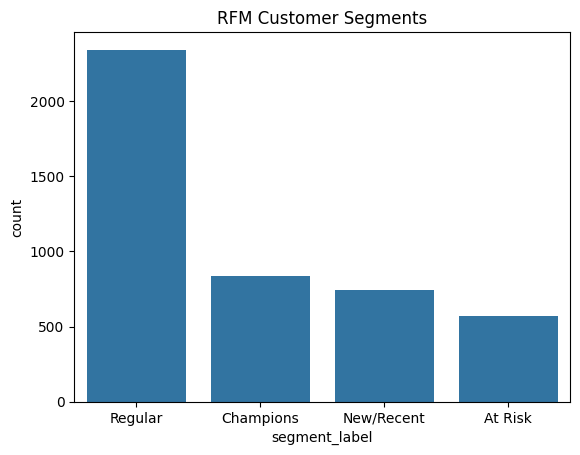

segment_label
Regular       2345
Champions      838
New/Recent     745
At Risk        572
Name: count, dtype: int64


In [35]:
snapshot_date = transaction['Date'].max() + pd.Timedelta(days=1)

rfm = transaction.groupby('account_id').agg(
    recency=('Date', lambda x: (snapshot_date - x.max()).days),
    frequency=('trans_id', 'count'),
    monetary=('amount', 'sum')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])
rfm['RFM_segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

def label_segment(row):
    if row['R_score'] in [4,5] and row['F_score'] in [4,5]: return 'Champions'
    if row['R_score'] in [1,2] and row['F_score'] in [1,2]: return 'At Risk'
    if row['R_score'] in [4,5] and row['F_score'] in [1,2]: return 'New/Recent'
    return 'Regular'
rfm['segment_label'] = rfm.apply(label_segment, axis=1)

sns.countplot(data=rfm, x='segment_label', order=rfm['segment_label'].value_counts().index)
plt.title("RFM Customer Segments"); plt.show()
print(rfm['segment_label'].value_counts())

                   mean  count
amount_bucket                 
<50K           0.039683    126
50-100K        0.100559    179
100-200K       0.093750    192
200K+          0.188889    180


/tmp/ipykernel_986/826409216.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_bucket = loan.groupby('amount_bucket')['is_default_flag'].agg(['mean','count'])


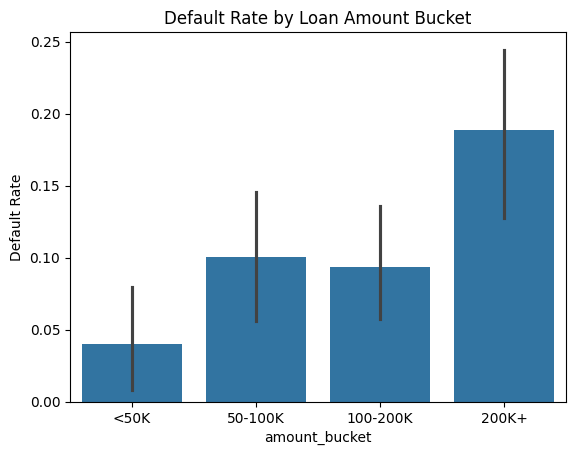

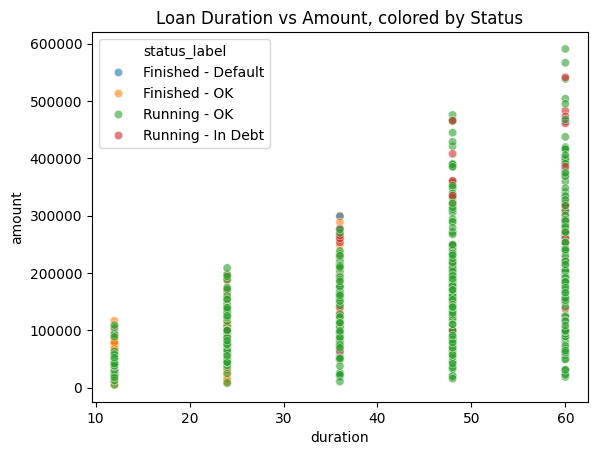

In [36]:
loan['amount_bucket'] = pd.cut(loan['amount'], bins=[0,50000,100000,200000,500000],
                                labels=['<50K','50-100K','100-200K','200K+'])
default_by_bucket = loan.groupby('amount_bucket')['is_default_flag'].agg(['mean','count'])
print(default_by_bucket)

sns.barplot(data=loan, x='amount_bucket', y='is_default_flag')
plt.title("Default Rate by Loan Amount Bucket"); plt.ylabel("Default Rate"); plt.show()

sns.scatterplot(data=loan, x='duration', y='amount', hue='status_label', alpha=0.6)
plt.title("Loan Duration vs Amount, colored by Status"); plt.show()

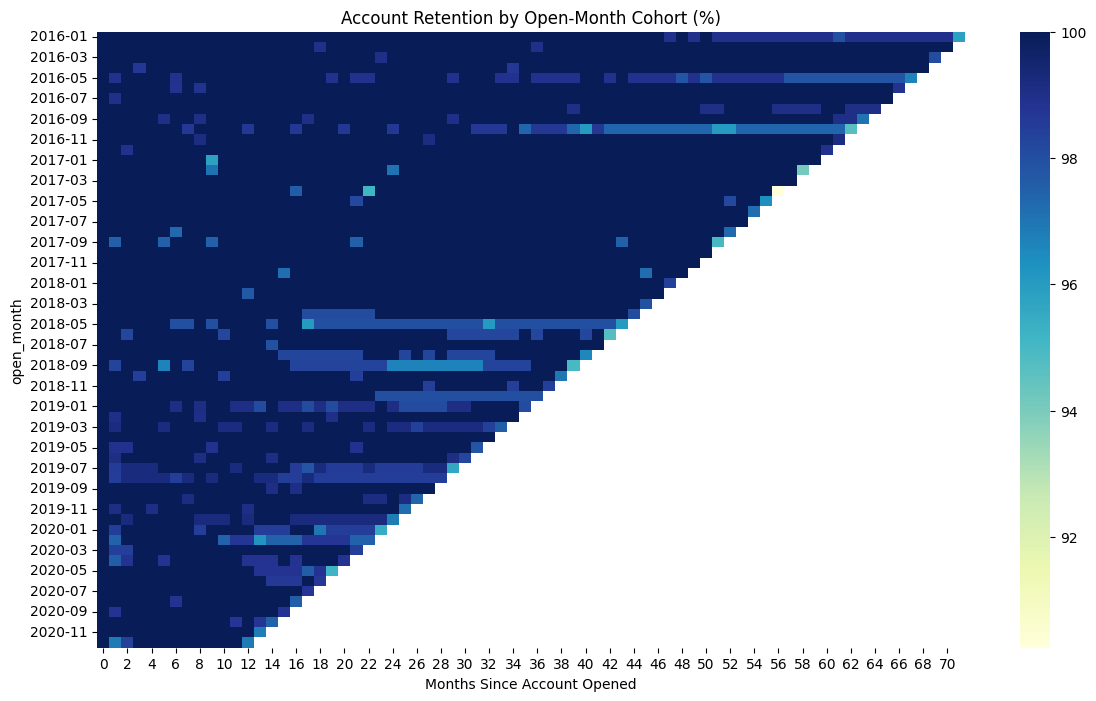

In [37]:
account['open_month'] = account['open_date'].dt.to_period('M')
txn_with_cohort = transaction.merge(account[['account_id','open_month']], on='account_id')
txn_with_cohort['txn_month'] = txn_with_cohort['Date'].dt.to_period('M')
txn_with_cohort['months_since_open'] = (txn_with_cohort['txn_month'] - txn_with_cohort['open_month']).apply(lambda x: x.n)

cohort_pivot = txn_with_cohort.groupby(['open_month','months_since_open'])['account_id'].nunique().unstack(0)
cohort_size = cohort_pivot.iloc[0]
retention = cohort_pivot.divide(cohort_size, axis=1) * 100

plt.figure(figsize=(14,8))
sns.heatmap(retention.T, cmap='YlGnBu', annot=False)
plt.title("Account Retention by Open-Month Cohort (%)")
plt.xlabel("Months Since Account Opened"); plt.show()

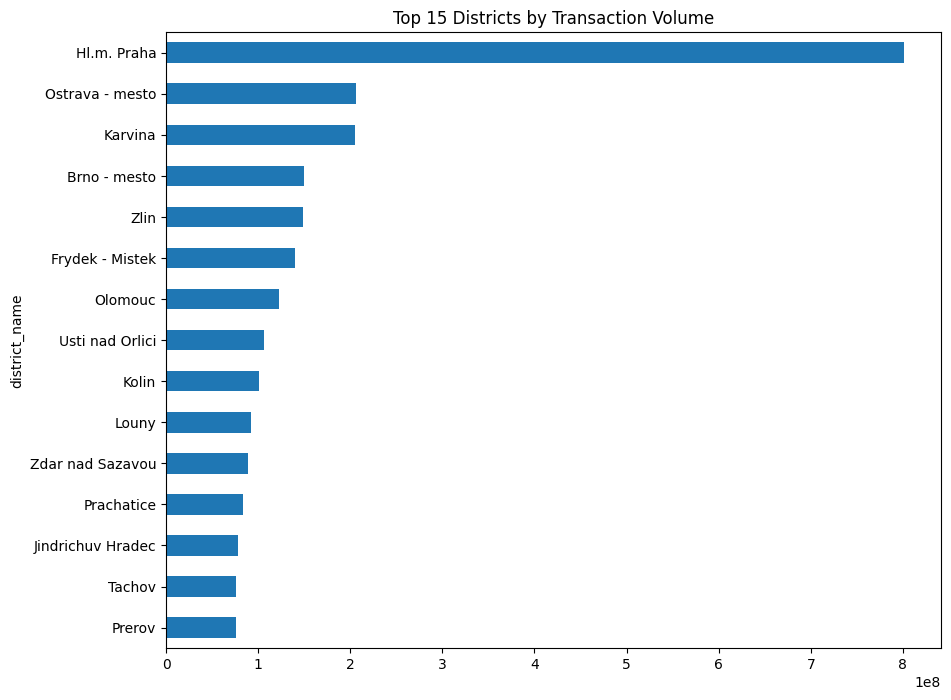

In [39]:
district_summary = account_full.groupby('A2').agg(
    num_accounts=('account_id','count'),
    avg_salary=('A10','first'), # Corrected to 'A10' for avg_salary
    total_txn_volume=('total_txn_volume','sum'),
    avg_txn_amount=('avg_txn_amount','mean')
).sort_values('total_txn_volume', ascending=False)

# Rename the index for better readability in the plot
district_summary.index.name = 'district_name'

fig, ax = plt.subplots(figsize=(10,8))
district_summary.head(15)['total_txn_volume'].plot(kind='barh', ax=ax)
ax.set_title("Top 15 Districts by Transaction Volume"); ax.invert_yaxis()
plt.show()

In [47]:
DB_USER = "avnadmin"
DB_PASS = "AVNS_zLSFTsrwQ9YUeZot1Sq"
DB_HOST = "mysql-10d0889e-ujjalsarkar7674-75f6.g.aivencloud.com"
DB_PORT = "12763"          # Aiven's assigned port
DB_NAME = "defaultdb"

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    f"?ssl_ca=ca.pem"
)

# Quick connection test
with engine.connect() as conn:
    print(conn.execute(text("SELECT VERSION()")).fetchone())

('8.4.8',)


In [51]:
from sqlalchemy import MetaData, Table, Column, BigInteger, Text, Float, DateTime, Integer, Boolean, String
from sqlalchemy.schema import PrimaryKeyConstraint

# Initialize metadata
metadata = MetaData()

# --- Create Table Schemas Manually (with Primary Keys) ---
# Define all cleaned dataframes first

district_clean = district.rename(columns={
    'A1':'district_id','A2':'district_name','A3':'region','A4':'num_inhabitants',
    'A9':'num_cities','A10':'urban_ratio','A11':'avg_salary',
    'A13':'unemployment_rate','A14':'entrepreneurs_per_1000','A16':'crimes_committed_2018'
})[['district_id','district_name','region','num_inhabitants','num_cities',
    'urban_ratio','avg_salary','unemployment_rate','entrepreneurs_per_1000','crimes_committed_2018']]

client_clean = client[['client_id','district_id','gender','birth_date','age','age_group']]

account_clean = account.rename(columns={'account_id':'account_id','Account_type':'account_type'})[
    ['account_id','district_id','frequency','open_date','account_type']
]

disp_clean = disp.rename(columns={'type':'disposition_type'})

card_clean = card.rename(columns={'type':'card_type'})[['card_id','disp_id','card_type','issue_date']]

loan_clean = loan[['loan_id','account_id','loan_date','amount','duration','payments',
                    'status','status_label','is_default_flag']].rename(columns={'status':'status_code'})

order_clean = order.rename(columns={'Bank_to':'bank_to'})[['order_id','account_id','bank_to','account_to','amount']]

transaction_clean = transaction.rename(columns={
    'trans_id':'trans_id','account_id':'account_id','Date':'trans_date',
    'Type':'trans_type','operation':'operation','amount':'amount','balance':'balance',
    'Purpose':'purpose','bank':'bank','account_partern_id':'account_partner_id'
})[['trans_id','account_id','trans_date','trans_type','operation','amount',
    'balance','purpose','bank','account_partner_id','is_outlier']]

# Now define the SQLAlchemy Tables with explicit primary keys
clean_district_table = Table(
    'clean_district', metadata,
    Column('district_id', BigInteger, primary_key=True, autoincrement=False),
    Column('district_name', Text),
    Column('region', Text),
    Column('num_inhabitants', BigInteger),
    Column('num_cities', BigInteger),
    Column('urban_ratio', Float(53)),
    Column('avg_salary', BigInteger),
    Column('unemployment_rate', Float(53)),
    Column('entrepreneurs_per_1000', BigInteger),
    Column('crimes_committed_2018', BigInteger)
)

clean_client_table = Table(
    'clean_client', metadata,
    Column('client_id', BigInteger, primary_key=True, autoincrement=False),
    Column('district_id', BigInteger),
    Column('gender', String(1)),
    Column('birth_date', DateTime),
    Column('age', BigInteger),
    Column('age_group', Text)
)

clean_account_table = Table(
    'clean_account', metadata,
    Column('account_id', BigInteger, primary_key=True, autoincrement=False),
    Column('district_id', BigInteger),
    Column('frequency', Text),
    Column('open_date', DateTime),
    Column('account_type', Text)
)

clean_disposition_table = Table(
    'clean_disposition', metadata,
    Column('disp_id', BigInteger, primary_key=True, autoincrement=False),
    Column('client_id', BigInteger),
    Column('account_id', BigInteger),
    Column('disposition_type', Text)
)

clean_card_table = Table(
    'clean_card', metadata,
    Column('card_id', BigInteger, primary_key=True, autoincrement=False),
    Column('disp_id', BigInteger),
    Column('card_type', Text),
    Column('issue_date', DateTime)
)

clean_loan_table = Table(
    'clean_loan', metadata,
    Column('loan_id', BigInteger, primary_key=True, autoincrement=False),
    Column('account_id', BigInteger),
    Column('loan_date', DateTime),
    Column('amount', BigInteger),
    Column('duration', Integer),
    Column('payments', Float(53)),
    Column('status_code', String(1)),
    Column('status_label', Text),
    Column('is_default_flag', Boolean)
)

clean_order_table = Table(
    'clean_order', metadata,
    Column('order_id', BigInteger, primary_key=True, autoincrement=False),
    Column('account_id', BigInteger),
    Column('bank_to', Text),
    Column('account_to', BigInteger),
    Column('amount', Float(53))
)

clean_transaction_table = Table(
    'clean_transaction', metadata,
    Column('trans_id', BigInteger, primary_key=True, autoincrement=False),
    Column('account_id', BigInteger),
    Column('trans_date', DateTime),
    Column('trans_type', Text),
    Column('operation', Text),
    Column('amount', Float(53)),
    Column('balance', Float(53)),
    Column('purpose', Text),
    Column('bank', Text),
    Column('account_partner_id', BigInteger),
    Column('is_outlier', Boolean)
)

# Drop existing tables and create all tables with primary keys
# This ensures 'replace' semantics for the tables themselves before inserting data
metadata.drop_all(engine)
metadata.create_all(engine)

# Push — now using if_exists='append' to add data to the pre-created tables, index=False as PKs are defined
district_clean.to_sql('clean_district', engine, if_exists='append', index=False, chunksize=1000)
client_clean.to_sql('clean_client', engine, if_exists='append', index=False, chunksize=1000)
account_clean.to_sql('clean_account', engine, if_exists='append', index=False, chunksize=1000)
disp_clean.to_sql('clean_disposition', engine, if_exists='append', index=False, chunksize=1000)
card_clean.to_sql('clean_card', engine, if_exists='append', index=False, chunksize=1000)
loan_clean.to_sql('clean_loan', engine, if_exists='append', index=False, chunksize=1000)
order_clean.to_sql('clean_order', engine, if_exists='append', index=False, chunksize=1000)
transaction_clean.to_sql('clean_transaction', engine, if_exists='append', index=False, chunksize=5000)

1048575

In [53]:
with engine.connect() as conn:
    # Primary keys were already defined during table creation in the previous cell.
    # Attempting to add them again here results in 'Multiple primary key defined' error.
    # Removed ALTER TABLE ADD PRIMARY KEY statements.

    conn.execute(text("CREATE INDEX idx_trans_account ON clean_transaction(account_id)"))
    conn.execute(text("CREATE INDEX idx_trans_account_date ON clean_transaction(account_id, trans_date)"))
    conn.execute(text("CREATE INDEX idx_loan_account ON clean_loan(account_id)"))
    conn.execute(text("CREATE INDEX idx_disp_account ON clean_disposition(account_id)"))
    conn.execute(text("CREATE INDEX idx_disp_client ON clean_disposition(client_id)"))
    conn.execute(text("CREATE INDEX idx_card_disp ON clean_card(disp_id)"))
    conn.commit()

In [54]:
views_sql = """
CREATE OR REPLACE VIEW dim_customer AS
SELECT
    c.client_id, c.gender, c.birth_date, c.age, c.age_group,
    c.district_id, d.district_name, d.region, d.avg_salary, d.unemployment_rate,
    COUNT(DISTINCT disp.account_id) AS num_accounts,
    COUNT(DISTINCT card.card_id) AS num_cards,
    COUNT(DISTINCT loan.loan_id) AS num_loans
FROM clean_client c
LEFT JOIN clean_district d ON c.district_id = d.district_id
LEFT JOIN clean_disposition disp ON c.client_id = disp.client_id
LEFT JOIN clean_card card ON disp.disp_id = card.disp_id
LEFT JOIN clean_loan loan ON disp.account_id = loan.account_id AND disp.disposition_type = 'OWNER'
GROUP BY c.client_id, c.gender, c.birth_date, c.age, c.age_group,
         c.district_id, d.district_name, d.region, d.avg_salary, d.unemployment_rate;

CREATE OR REPLACE VIEW dim_account AS
SELECT
    a.account_id, a.frequency, a.open_date, a.account_type,
    a.district_id AS branch_district_id, d.district_name AS branch_district_name,
    TIMESTAMPDIFF(YEAR, a.open_date, CURDATE()) AS account_tenure_years
FROM clean_account a
LEFT JOIN clean_district d ON a.district_id = d.district_id;

CREATE OR REPLACE VIEW fact_transaction AS
SELECT
    t.trans_id, t.account_id, t.trans_date,
    DATE_FORMAT(t.trans_date, '%Y-%m-01') AS trans_month,
    YEAR(t.trans_date) AS trans_year,
    t.trans_type, t.operation, t.amount, t.balance, t.purpose, t.bank, t.is_outlier
FROM clean_transaction t;

CREATE OR REPLACE VIEW fact_loan AS
SELECT
    l.loan_id, l.account_id, l.loan_date, YEAR(l.loan_date) AS loan_year,
    l.amount, l.duration, l.payments, l.status_label, l.is_default_flag,
    a.district_id AS branch_district_id
FROM clean_loan l
LEFT JOIN clean_account a ON l.account_id = a.account_id;

CREATE OR REPLACE VIEW fact_order AS
SELECT order_id, account_id, bank_to, amount FROM clean_order;

CREATE OR REPLACE VIEW bridge_card_account AS
SELECT card.card_id, card.card_type, card.issue_date, disp.account_id, disp.client_id
FROM clean_card card
JOIN clean_disposition disp ON card.disp_id = disp.disp_id;
"""

with engine.connect() as conn:
    for statement in views_sql.strip().split(';'):
        if statement.strip():
            conn.execute(text(statement))
    conn.commit()

In [57]:
def run_query(sql):
    return pd.read_sql(text(sql), engine)

# Q1 — Customer demographic profile across districts
q1 = run_query("""
    SELECT district_name, region, avg_salary, unemployment_rate,
           COUNT(client_id) AS num_customers, ROUND(AVG(age),1) AS avg_age
    FROM dim_customer
    GROUP BY district_id, district_name, region, avg_salary, unemployment_rate
    ORDER BY num_customers DESC;
""")
display(q1)
print()

# Q2 — Bank performance year-wise and month-wise
q2 = run_query("""
    SELECT trans_year, trans_month, SUM(amount) AS monthly_volume, COUNT(*) AS txn_count
    FROM fact_transaction
    GROUP BY trans_year, trans_month
    ORDER BY trans_month;
""")
display(q2)
print()

# Q3 — Account types and profitability
q3 = run_query("""
    SELECT a.frequency, COUNT(*) AS num_accounts,
           ROUND(AVG(t.amount),2) AS avg_txn_amount
    FROM dim_account a
    JOIN fact_transaction t ON a.account_id = t.account_id
    GROUP BY a.frequency;
""")
display(q3)
print()

# Q4 — Card usage & profitability
q4 = run_query("""
    SELECT b.card_type, COUNT(DISTINCT b.card_id) AS card_count,
           SUM(CASE WHEN t.operation LIKE '%%Credit card%%' THEN t.amount ELSE 0 END) AS card_driven_volume
    FROM bridge_card_account b
    JOIN fact_transaction t ON b.account_id = t.account_id
    GROUP BY b.card_type;
""")
display(q4)
print()

# Q5 — Major expenses
q5 = run_query("""
    SELECT purpose, SUM(amount) AS total_outflow, COUNT(*) AS txn_count
    FROM fact_transaction
    WHERE trans_type = 'Withdrawal'
    GROUP BY purpose
    ORDER BY total_outflow DESC;
""")
display(q5)
print()

# Q6 — Loan portfolio analysis
q6 = run_query("""
    SELECT status_label, COUNT(*) AS num_loans, SUM(amount) AS total_amount,
           ROUND(AVG(duration),1) AS avg_duration
    FROM fact_loan
    GROUP BY status_label;
""")
display(q6)
print()

# Q7 — Customer service signals (negative balance incidents)
q7 = run_query("""
    SELECT account_id, COUNT(*) AS negative_balance_events
    FROM fact_transaction
    WHERE balance < 0
    GROUP BY account_id
    ORDER BY negative_balance_events DESC
    LIMIT 20;
""")
display(q7)
print()

# Q8 — Product holding / whitespace
q8 = run_query("""
    SELECT age_group, gender,
           ROUND(AVG(num_accounts + num_cards + num_loans),2) AS avg_products_held,
           COUNT(*) AS customer_count
    FROM dim_customer
    GROUP BY age_group, gender
    ORDER BY avg_products_held DESC;
""")
display(q8)
print()

,district_name,region,avg_salary,unemployment_rate,num_customers,avg_age
0,Hl.m. Praha,Prague,12541,0.43,663,49.9
1,Ostrava - mesto,north Moravia,10673,5.44,180,49.2
2,Karvina,north Moravia,10177,7.75,169,50.0
3,Brno - mesto,south Moravia,9897,1.96,155,48.5
4,Zlin,south Moravia,9624,2.31,109,50.6
...,...,...,...,...,...,...
72,Pribram,central Bohemia,8754,4.31,44,51.2
73,Jihlava,south Moravia,8757,3.95,44,50.8
74,Znojmo,south Moravia,8403,5.72,44,51.0
75,Karlovy Vary,west Bohemia,8991,2.01,43,52.1


,trans_year,trans_month,monthly_volume,txn_count
0,2016,2016-01-01,702159.0,177
1,2016,2016-02-01,2726934.0,395
2,2016,2016-03-01,4730331.0,676
3,2016,2016-04-01,7378392.0,913
4,2016,2016-05-01,11680791.0,1306
...,...,...,...,...
67,2021,2021-08-01,150641214.0,25622
68,2021,2021-09-01,148299583.0,25450
69,2021,2021-10-01,151891490.0,25689
70,2021,2021-11-01,148843990.0,25341


,frequency,num_accounts,avg_txn_amount
0,Monthly Statement,962231,5518.30
1,Weekly Statement,62058,10650.40
2,Statement After Transaction,24286,10704.77


,card_type,card_count,card_driven_volume
0,classic,659,11705200.0
1,gold,88,2638200.0
2,junior,145,3083100.0


,purpose,total_outflow,txn_count
0,None,2.433799e+09,340870
1,Household,4.984506e+08,118057
2,Loan Payment,5.525300e+07,13580
3,Insurance Payment,2.417519e+07,18500
4,Payment on Statement,2.744045e+06,155832
5,Sanction Interest,3.581700e+04,1527


,status_label,num_loans,total_amount,avg_duration
0,Finished - OK,203,18603216.0,22.2
1,Finished - Default,31,4362348.0,25.5
2,Running - In Debt,45,11217804.0,46.1
3,Running - OK,403,69078372.0,43.4


,account_id,negative_balance_events
0,2335,119
1,3678,109
2,2260,99
3,2305,73
4,3374,70
5,5343,63
6,1539,61
7,5092,52
8,5429,51
9,4356,47


,age_group,gender,avg_products_held,customer_count
0,18-25,F,1.48,180
1,18-25,M,1.38,202
2,51-65,M,1.36,719
3,51-65,F,1.35,748
4,36-50,F,1.35,705
5,26-35,M,1.34,474
6,36-50,M,1.33,735
7,26-35,F,1.32,518
8,65+,M,1.10,590
9,65+,F,1.02,493


In [58]:
# Q9 — Top 10 highest-value customers by total transaction volume
q9 = run_query("""
    SELECT c.client_id, c.age, c.gender, c.district_name,
           SUM(t.amount) AS total_txn_volume,
           RANK() OVER (ORDER BY SUM(t.amount) DESC) AS value_rank
    FROM dim_customer c
    JOIN clean_disposition d ON c.client_id = d.client_id
    JOIN fact_transaction t ON d.account_id = t.account_id
    GROUP BY c.client_id, c.age, c.gender, c.district_name
    ORDER BY total_txn_volume DESC
    LIMIT 10;
""")
display(q9)

# Q10 — Month-over-month new account growth
q10 = run_query("""
    WITH monthly_new AS (
        SELECT DATE_FORMAT(open_date, '%Y-%m-01') AS open_month,
               COUNT(*) AS new_accounts
        FROM dim_account
        GROUP BY open_month
    )
    SELECT open_month, new_accounts,
           LAG(new_accounts) OVER (ORDER BY open_month) AS prev_month,
           ROUND((new_accounts - LAG(new_accounts) OVER (ORDER BY open_month))
                 / LAG(new_accounts) OVER (ORDER BY open_month) * 100, 1) AS mom_growth_pct
    FROM monthly_new
    ORDER BY open_month;
""")
display(q10)

# Q11 — Loan default rate by district
q11 = run_query("""
    SELECT d.district_name, d.avg_salary, d.unemployment_rate,
           COUNT(l.loan_id) AS total_loans,
           SUM(l.is_default_flag) AS defaulted_loans,
           ROUND(SUM(l.is_default_flag) / COUNT(l.loan_id) * 100, 1) AS default_rate_pct
    FROM fact_loan l
    JOIN clean_district d ON l.branch_district_id = d.district_id
    GROUP BY d.district_name, d.avg_salary, d.unemployment_rate
    HAVING COUNT(l.loan_id) >= 5
    ORDER BY default_rate_pct DESC;
""")
display(q11)

# Q12 — Running (cumulative) deposit balance per account over time
q12 = run_query("""
    SELECT account_id, trans_date, amount,
           SUM(amount) OVER (PARTITION BY account_id ORDER BY trans_date
                              ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS running_balance
    FROM fact_transaction
    WHERE account_id = (SELECT account_id FROM fact_transaction LIMIT 1)
    ORDER BY trans_date
    LIMIT 50;
""")
display(q12)

# Q13 — Card type profitability: avg transaction value per card type
q13 = run_query("""
    SELECT b.card_type,
           COUNT(DISTINCT b.card_id) AS num_cards,
           ROUND(AVG(t.amount), 2) AS avg_txn_value,
           ROUND(SUM(t.amount) / COUNT(DISTINCT b.card_id), 2) AS avg_volume_per_card
    FROM bridge_card_account b
    JOIN fact_transaction t ON b.account_id = t.account_id
    GROUP BY b.card_type
    ORDER BY avg_volume_per_card DESC;
""")
display(q13)

# Q14 — Single-account vs multi-account customers: who transacts more
q14 = run_query("""
    WITH account_counts AS (
        SELECT client_id, COUNT(DISTINCT account_id) AS num_accounts
        FROM clean_disposition
        GROUP BY client_id
    )
    SELECT CASE WHEN ac.num_accounts > 1 THEN 'Multi-Account' ELSE 'Single-Account' END AS segment,
           COUNT(DISTINCT ac.client_id) AS num_customers,
           ROUND(AVG(t.amount), 2) AS avg_txn_amount
    FROM account_counts ac
    JOIN clean_disposition d ON ac.client_id = d.client_id
    JOIN fact_transaction t ON d.account_id = t.account_id
    GROUP BY segment;
""")
display(q14)

# Q15 — Loan concentration relative to district population (risk exposure per capita)
q15 = run_query("""
    SELECT d.district_name, d.num_inhabitants,
           SUM(l.amount) AS total_loan_value,
           ROUND(SUM(l.amount) / d.num_inhabitants, 2) AS loan_value_per_inhabitant
    FROM fact_loan l
    JOIN clean_district d ON l.branch_district_id = d.district_id
    GROUP BY d.district_name, d.num_inhabitants
    ORDER BY loan_value_per_inhabitant DESC
    LIMIT 10;
""")
display(q15)

# Q16 — Owner vs Disponent (user) disposition: who transacts differently
q16 = run_query("""
    SELECT d.disposition_type,
           COUNT(DISTINCT d.client_id) AS num_clients,
           ROUND(AVG(t.amount), 2) AS avg_txn_amount,
           COUNT(t.trans_id) AS total_transactions
    FROM clean_disposition d
    JOIN fact_transaction t ON d.account_id = t.account_id
    GROUP BY d.disposition_type;
""")
display(q16)

# Q17 — At-risk customers: loan default AND negative balance history
q17 = run_query("""
    SELECT DISTINCT c.client_id, c.district_name, l.status_label,
           COUNT(t.trans_id) AS negative_balance_events
    FROM dim_customer c
    JOIN clean_disposition d ON c.client_id = d.client_id AND d.disposition_type = 'OWNER'
    JOIN fact_loan l ON d.account_id = l.account_id
    JOIN fact_transaction t ON d.account_id = t.account_id AND t.balance < 0
    WHERE l.is_default_flag = 1
    GROUP BY c.client_id, c.district_name, l.status_label
    ORDER BY negative_balance_events DESC
    LIMIT 20;
""")
display(q17)

# Q18 — Weekday vs weekend transaction pattern
q18 = run_query("""
    SELECT
        CASE WHEN DAYOFWEEK(trans_date) IN (1,7) THEN 'Weekend' ELSE 'Weekday' END AS day_type,
        COUNT(*) AS txn_count,
        ROUND(AVG(amount), 2) AS avg_amount,
        SUM(amount) AS total_volume
    FROM fact_transaction
    GROUP BY day_type;
""")
display(q18)

,client_id,age,gender,district_name,total_txn_volume,value_rank
0,255,52,F,Plzen - jih,7618770.0,1
1,4251,43,M,Chrudim,7401108.0,2
2,4252,50,F,Chrudim,7401108.0,2
3,3335,36,M,Praha - zapad,7379619.0,4
4,1359,52,F,Hl.m. Praha,7367818.0,5
5,1360,57,M,Hl.m. Praha,7367818.0,5
6,548,66,M,Semily,7338235.0,7
7,3430,52,M,Beroun,7334261.0,8
8,1239,27,F,Praha - zapad,7327116.0,9
9,2688,36,F,Prostejov,7325624.0,10


,open_month,new_accounts,prev_month,mom_growth_pct
0,2016-01-01,96,NaN,NaN
1,2016-02-01,98,96.0,2.1
2,2016-03-01,104,98.0,6.1
3,2016-04-01,77,104.0,-26.0
4,2016-05-01,91,77.0,18.2
5,2016-06-01,88,91.0,-3.3
6,2016-07-01,99,88.0,12.5
7,2016-08-01,102,99.0,3.0
8,2016-09-01,103,102.0,1.0
9,2016-10-01,75,103.0,-27.2


,district_name,avg_salary,unemployment_rate,total_loans,defaulted_loans,default_rate_pct
0,Strakonice,8547,3.64,6,3.0,50.0
1,Bruntal,8110,6.55,6,3.0,50.0
2,Opava,8746,3.74,8,3.0,37.5
3,Beroun,8980,2.21,6,2.0,33.3
4,Kutna Hora,8546,4.02,9,3.0,33.3
...,...,...,...,...,...,...
60,Pardubice,9538,1.81,10,0.0,0.0
61,Louny,8965,8.23,13,0.0,0.0
62,Zdar nad Sazavou,8512,4.12,7,0.0,0.0
63,Teplice,9317,7.07,6,0.0,0.0


,account_id,trans_date,amount,running_balance
0,1,2018-03-24,1000.0,1000.0
1,1,2018-04-13,3679.0,4679.0
2,1,2018-04-23,12600.0,17279.0
3,1,2018-04-30,19.0,17298.0
4,1,2018-05-13,3679.0,20977.0
5,1,2018-05-23,2100.0,23077.0
6,1,2018-05-31,79.0,23156.0
7,1,2018-06-13,3679.0,26835.0
8,1,2018-06-22,200.0,27035.0
9,1,2018-06-30,101.0,27136.0


,card_type,num_cards,avg_txn_value,avg_volume_per_card
0,gold,88,9131.82,2653728.95
1,classic,659,8657.96,2083742.95
2,junior,145,7657.96,1905406.10


,segment,num_customers,avg_txn_amount
0,Single-Account,5369,5891.0


,district_name,num_inhabitants,total_loan_value,loan_value_per_inhabitant
0,Prachatice,51428,2356692.0,45.83
1,Jesenik,42821,1938432.0,45.27
2,Rokycany,45714,1329204.0,29.08
3,Kutna Hora,77963,2095980.0,26.88
4,Svitavy,102609,2100084.0,20.47
5,Kolin,95616,1901160.0,19.88
6,Beroun,75232,1460796.0,19.42
7,Plzen - jih,67298,1294188.0,19.23
8,Tachov,51313,959784.0,18.70
9,Plzen - sever,72541,1338984.0,18.46


,disposition_type,num_clients,avg_txn_amount,total_transactions
0,OWNER,4500,5942.15,1048575
1,USER,869,5629.12,204827


,client_id,district_name,status_label,negative_balance_events
0,2823,Karvina,Running - In Debt,119
1,4433,Hl.m. Praha,Running - In Debt,109
2,6567,Kolin,Finished - Default,39
3,6895,Havlickuv Brod,Running - In Debt,33
4,4968,Svitavy,Running - In Debt,33
5,1327,Strakonice,Finished - Default,30
6,7166,Cesky Krumlov,Finished - Default,29
7,7348,Kutna Hora,Running - In Debt,28
8,5565,Beroun,Running - In Debt,27
9,9196,Tabor,Finished - Default,27


,day_type,txn_count,avg_amount,total_volume
0,Weekend,297854,5977.24,1.780346e+09
1,Weekday,750721,5928.23,4.450447e+09
